# Service Provider Survey: Language Barriers in Refugee Services

## Data cleaning and preliminary analysis notebook

This notebook prepares and analyses the updated KoboToolbox service-provider survey data.

### Objectives
- audit the raw exports and form versions;
- verify consent, eligibility, duplicates, and completeness;
- harmonise variables stored in different columns across form versions;
- create one analysis-ready dataset;
- produce descriptive tables and charts;
- identify preliminary findings for the final report.

> **Important:** The dataset contains only six respondents. Results are exploratory and should be reported mainly as counts, for example **4 out of 6 respondents**, with percentages used only as supporting information. No inferential statistical tests are appropriate at this stage.


In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Suppress non-critical warnings for a cleaner notebook output.
warnings.filterwarnings("ignore")

# Increase pandas display width for better notebook tables.
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 120)

# Define the main data folder and the two KoboToolbox exports used in this analysis.
DATA_DIR = Path("./data")
LABELS_FILE = DATA_DIR / "Service_Provider_Survey_Language_Barriers_in_Refugee_Services_-_all_versions_-_labels_-_2026-08-01-23-07-11.xlsx"
XML_FILE = DATA_DIR / "Service_Provider_Survey_Language_Barriers_in_Refugee_Services_-_all_versions_-_False_-_2026-08-01-23-07-14.xlsx"

print("Labels file:", LABELS_FILE.name)
print("XML file:", XML_FILE.name)

Labels file: Service_Provider_Survey_Language_Barriers_in_Refugee_Services_-_all_versions_-_labels_-_2026-08-01-23-07-11.xlsx
XML file: Service_Provider_Survey_Language_Barriers_in_Refugee_Services_-_all_versions_-_False_-_2026-08-01-23-07-14.xlsx


## 1. Load the two KoboToolbox exports

The **labels export** is used for readable analysis.  
The **XML export** is retained for auditing technical variable names and form-version differences.


In [ ]:
# Load the two KoboToolbox exports into pandas DataFrames.
labels_raw = pd.read_excel(LABELS_FILE)
xml_raw = pd.read_excel(XML_FILE)

# Print basic dimensions to confirm the data loaded correctly.
print("Labels export shape:", labels_raw.shape)
print("XML export shape:", xml_raw.shape)
print("Number of respondents:", len(labels_raw))
print("Number of columns:", labels_raw.shape[1])

display(labels_raw.head(3))

Labels export shape: (6, 193)
XML export shape: (6, 193)
Number of respondents: 6
Number of columns: 193


,start,end,I voluntarily agree to participate in this study. I understand that my data is anonymous and that I can withdraw at any time prior to submitting my responses.,Are you 18 years of age or older?,In which settlement or refugee-hosting area do you currently work?,Please specify which settlement or refugee-hosting area do you currently work.,What is your current role?,What is your current role?/Healthcare Worker,What is your current role?/Legal Aid Officer / Protection Officer,What is your current role?/Social Worker,What is your current role?/Interpreter,What is your current role?/Community Outreach Worker,What is your current role?/Volunteer,What is your current role?/Other frontline humanitarian personnel,What is your current role?/Other,Please specify your role,How often do you interact with refugee clients whose primary language differs from the language you use to deliver services?,Which sector best describes your role?,Which sector best describes your role?.1,Which language(s) do you primarily use to deliver services to clients?,Which language(s) do you primarily use to deliver services to clients?/English,Which language(s) do you primarily use to deliver services to clients?/Kiswahili,Which language(s) do you primarily use to deliver services to clients?/Kinyarwanda,Which language(s) do you primarily use to deliver services to clients?/Kakwa,Which language(s) do you primarily use to deliver services to clients?/Bari,Which language(s) do you primarily use to deliver services to clients?/Nuer,Which language(s) do you primarily use to deliver services to clients?/Juba Arabic,Which language(s) do you primarily use to deliver services to clients?/Acholi,Which language(s) do you primarily use to deliver services to clients?/Madi,Which language(s) do you primarily use to deliver services to clients?/Zande,Which language(s) do you primarily use to deliver services to clients?/Other,Which language(s) do your refugee clients most commonly speak?,Which language(s) do your refugee clients most commonly speak?/English,Which language(s) do your refugee clients most commonly speak?/Kakwa,Which language(s) do your refugee clients most commonly speak?/Bari,Which language(s) do your refugee clients most commonly speak?/Nuer,Which language(s) do your refugee clients most commonly speak?/Juba Arabic,Which language(s) do your refugee clients most commonly speak?/Acholi,Which language(s) do your refugee clients most commonly speak?/Madi,Which language(s) do your refugee clients most commonly speak?/Zande,Which language(s) do your refugee clients most commonly speak?/Other,Please specify other language(s),Which languages among your client caseload are hardest to find interpretation or translation support for?,Which languages among your client caseload are hardest to find interpretation or translation support for?/English,Which languages among your client caseload are hardest to find interpretation or translation support for?/Kakwa,Which languages among your client caseload are hardest to find interpretation or translation support for?/Bari,Which languages among your client caseload are hardest to find interpretation or translation support for?/Nuer,Which languages among your client caseload are hardest to find interpretation or translation support for?/Juba Arabic,Which languages among your client caseload are hardest to find interpretation or translation support for?/Acholi,Which languages among your client caseload are hardest to find interpretation or translation support for?/Madi,Which languages among your client caseload are hardest to find interpretation or translation support for?/Zande,Which languages among your client caseload are hardest to find interpretation or translation support for?/Other,"Which languages among your client caseload are hardest to find interpretation or translation support for?/None, support is adequate for all languages I encounter",Please specify other language(s).1,"In a typical week, how often do you 

## 2. Helper functions for harmonising form versions

KoboToolbox exported some logically identical questions into different columns because the form was revised.


In [ ]:
def base_header(column_name):
    # Normalize a column header by removing duplicate suffixes from pandas.
    return re.sub(r"\.\d+$", "", str(column_name))

def matching_columns(df, exact=None, startswith=None, contains=None):
    # Return matching columns by exact name, prefix, or substring.
    matches = []
    for col in df.columns:
        base = base_header(col)
        if exact is not None and base == exact:
            matches.append(col)
        elif startswith is not None and base.startswith(startswith):
            matches.append(col)
        elif contains is not None and contains.lower() in base.lower():
            matches.append(col)
    return matches

def coalesce_columns(df, columns):
    # Return the first non-missing value across a list of candidate columns.
    columns = [c for c in columns if c in df.columns]
    if not columns:
        return pd.Series(pd.NA, index=df.index, dtype="object")
    return df[columns].replace(r"^\s*$", pd.NA, regex=True).bfill(axis=1).iloc[:, 0]

def scalar(question):
    # Combine duplicate columns containing the same readable question into one series.
    return coalesce_columns(labels_raw, matching_columns(labels_raw, exact=question))

def option_matrix(question):
    # Combine binary option columns for a select-multiple question across all form versions.
    grouped = {}
    prefix = question + "/"
    for col in labels_raw.columns:
        base = base_header(col)
        if base.startswith(prefix):
            option = base[len(prefix):]
            grouped.setdefault(option, []).append(col)

    result = pd.DataFrame(index=labels_raw.index)
    for option, cols in grouped.items():
        numeric = labels_raw[cols].apply(pd.to_numeric, errors="coerce")
        result[option] = numeric.max(axis=1, skipna=True).fillna(0).astype(int)
    return result

def clean_ordinal(series):
    # Convert values such as '3 - Sometimes' to readable text labels.
    return (
        series.astype("string")
        .str.replace("–", "-", regex=False)
        .str.replace(r"^\s*\d+\s*-\s*", "", regex=True)
        .str.strip()
        .replace({"<NA>": pd.NA})
    )

def ordinal_score(series):
    # Extract the leading numeric score from an ordinal response string.
    cleaned = series.astype("string").str.replace("–", "-", regex=False)
    return pd.to_numeric(cleaned.str.extract(r"^\s*(\d+)")[0], errors="coerce")

def frequency_table(series, include_missing=False):
    # Build a frequency table of response values and percentages.
    s = series.copy()
    if include_missing:
        s = s.fillna("Missing")
    else:
        s = s.dropna()
    counts = s.value_counts(dropna=False)
    denominator = len(s)
    table = pd.DataFrame({
        "Count": counts,
        "Percent": (counts / denominator * 100).round(1) if denominator else 0,
    })
    table.index.name = "Response"
    return table

def plot_counts(table, title, xlabel="Number of respondents"):
    # Create a horizontal bar chart from a frequency table.
    ax = table.sort_values("Count").plot.barh(
        y="Count", legend=False, figsize=(8, max(3, len(table) * 0.55))
    )
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    ax.bar_label(ax.containers[0], padding=3)
    plt.tight_layout()
    plt.show()

## 3. Raw-data audit and form versions

In [4]:
version_col = "__version__"
version_counts = labels_raw[version_col].value_counts(dropna=False).rename_axis("Form version").to_frame("Respondents")

audit_summary = pd.DataFrame({
    "Metric": [
        "Respondents",
        "Columns in labels export",
        "Columns in XML export",
        "Unique UUIDs",
        "Duplicate UUIDs",
        "Form versions",
    ],
    "Value": [
        len(labels_raw),
        labels_raw.shape[1],
        xml_raw.shape[1],
        labels_raw["_uuid"].nunique(dropna=True),
        labels_raw["_uuid"].duplicated().sum(),
        labels_raw[version_col].nunique(dropna=True),
    ],
})

display(audit_summary)
display(version_counts)


,Metric,Value
0,Respondents,6
1,Columns in labels export,193
2,Columns in XML export,193
3,Unique UUIDs,6
4,Duplicate UUIDs,0
5,Form versions,2


,Respondents
Form version,
v3D2RUwPgujSnoKKF5bmec,3
vdwK2FXRN6RJWDveLbqYGU,3


## 4. Data-quality checks

Checks: informed consent, age eligibility, duplicate UUIDs, timestamps, and survey duration.


In [ ]:
# Define the primary screening questions used for consent and age eligibility.
consent_question = (
    "I voluntarily agree to participate in this study. I understand that my data is anonymous "
    "and that I can withdraw at any time prior to submitting my responses."
 )
age_question = "Are you 18 years of age or older?"

# Convert Excel serial date values or datetime columns into pandas datetime series.
def excel_serial_to_datetime(series):
    if pd.api.types.is_datetime64_any_dtype(series):
        return pd.to_datetime(series, errors="coerce")
    numeric = pd.to_numeric(series, errors="coerce")
    return pd.Timestamp("1899-12-30") + pd.to_timedelta(numeric, unit="D")

start_dt = excel_serial_to_datetime(labels_raw["start"])
end_dt = excel_serial_to_datetime(labels_raw["end"])
submission_dt = excel_serial_to_datetime(labels_raw["_submission_time"])

# Build a quality audit table for each submission.
quality = pd.DataFrame({
    "respondent_id": labels_raw["_index"],
    "uuid": labels_raw["_uuid"],
    "form_version": labels_raw["__version__"],
    "consent": scalar(consent_question),
    "adult_18_plus": scalar(age_question),
    "start": start_dt,
    "end": end_dt,
    "submission_time": submission_dt,
})
quality["duration_minutes"] = ((quality["end"] - quality["start"]).dt.total_seconds() / 60).round(1)
quality["eligible"] = (
    quality["consent"].astype("string").str.lower().eq("yes")
    & quality["adult_18_plus"].astype("string").str.lower().eq("yes")
)
quality["duplicate_uuid"] = quality["uuid"].duplicated(keep=False)

# Display the submission-level audit, eligibility, and duplicate checks.
display(quality)
print("Eligible submissions:", int(quality["eligible"].sum()), "out of", len(quality))
print("Duplicate UUID records:", int(quality["duplicate_uuid"].sum()))

,respondent_id,uuid,form_version,consent,adult_18_plus,start,end,submission_time,duration_minutes,eligible,duplicate_uuid
0,1,5f649104-9b44-4873-8a30-7ee908771ec9,v3D2RUwPgujSnoKKF5bmec,Yes,Yes,2026-07-22 17:04:25.635,2026-07-22 17:34:09.900,2026-07-22 14:34:10,29.7,True,False
1,2,7f166b2a-2bf7-4b80-94f9-6127e52c53d9,v3D2RUwPgujSnoKKF5bmec,Yes,Yes,2026-07-23 14:00:24.256,2026-07-23 14:27:27.320,2026-07-23 11:27:30,27.1,True,False
2,3,b84780ef-8eac-4f18-9f37-2e011920ac84,v3D2RUwPgujSnoKKF5bmec,Yes,Yes,2026-07-23 15:25:38.939,2026-07-23 15:37:07.424,2026-07-23 12:37:08,11.5,True,False
3,4,b5c6c427-61b5-494b-8c55-2e767dbb8e5e,vdwK2FXRN6RJWDveLbqYGU,Yes,Yes,2026-07-28 09:33:25.795,2026-07-28 09:42:53.821,2026-07-28 06:42:55,9.5,True,False
4,5,1b62d855-1086-415f-ad35-e72f9df30b66,vdwK2FXRN6RJWDveLbqYGU,Yes,Yes,2026-07-28 10:26:59.119,2026-07-28 10:42:37.177,2026-07-28 07:42:39,15.6,True,False
5,6,fa8f3bfc-3793-4777-a4dd-f0afc14a87ca,vdwK2FXRN6RJWDveLbqYGU,Yes,Yes,2026-07-30 09:18:02.936,2026-07-30 09:20:52.698,2026-07-30 06:20:54,2.8,True,False


Eligible submissions: 6 out of 6
Duplicate UUID records: 0


## 5. Construct the harmonised analysis dataset

In [ ]:
# Start the cleaned dataset from the submission-quality audit table.
clean = quality.copy()

# Respondent profile fields and role/sector metadata.
clean["settlement"] = scalar("In which settlement or refugee-hosting area do you currently work?")
clean["settlement_other"] = scalar("Please specify which settlement or refugee-hosting area do you currently work.")
clean["current_role"] = scalar("What is your current role?")
clean["role_other"] = scalar("Please specify your role")
clean["sector"] = scalar("Which sector best describes your role?")

# Capture language context using select-multiple and scalar items.
service_language_q = "Which language(s) do you primarily use to deliver services to clients?"
client_language_q = "Which language(s) do your refugee clients most commonly speak?"
hardest_language_q = (
    "Which languages among your client caseload are hardest to find interpretation or translation support for?"
)

service_language_options = option_matrix(service_language_q)
client_language_options = option_matrix(client_language_q)
hardest_language_options = option_matrix(hardest_language_q)

clean["interaction_frequency"] = scalar(
    "In a typical week, how often do you interact with clients whose primary language differs from yours?"
)

# Harmonise core interpreter survey items across both new and old form versions.
rate_cols = [c for c in labels_raw.columns if re.fullmatch(r"Rate(?:\.\d+)?", str(c))]
rate_cols = sorted(
    rate_cols,
    key=lambda x: 0 if x == "Rate" else int(str(x).split(".")[-1]) + 1
)

availability_new = scalar("How would you rate the availability of professional interpreters in your workplace?")
informal_new = scalar(
    'How often do you rely on informal interpreters (family, community members, untrained staff) '
    'when a professional interpreter is unavailable?"'
)
overall_effectiveness_new = scalar(
    "Overall, how effective do you feel your communication is with language-discordant clients?"
)
machine_trust_new = scalar(
    "How much do you trust machine translation (e.g., translation apps) to accurately convey sensitive clinical or legal information?"
)
institutional_support_new = scalar(
    "How would you rate the institutional support (training, protocols, resourcing) available to help you manage language barriers?"
)

# Preserve older numeric `Rate` columns and combine them with the newer named items.
availability_old = labels_raw[rate_cols[0]] if len(rate_cols) > 0 else pd.Series(pd.NA, index=labels_raw.index)
informal_old = labels_raw[rate_cols[1]] if len(rate_cols) > 1 else pd.Series(pd.NA, index=labels_raw.index)
overall_effectiveness_old = labels_raw[rate_cols[14]] if len(rate_cols) > 14 else pd.Series(pd.NA, index=labels_raw.index)
machine_trust_old = labels_raw[rate_cols[15]] if len(rate_cols) > 15 else pd.Series(pd.NA, index=labels_raw.index)
institutional_support_old = labels_raw[rate_cols[16]] if len(rate_cols) > 16 else pd.Series(pd.NA, index=labels_raw.index)

# Use the newer labels when available; otherwise fall back to the old generic `Rate` values.
clean["professional_interpreter_availability_raw"] = pd.concat(
    [availability_new, availability_old], axis=1
).bfill(axis=1).iloc[:, 0]
clean["informal_interpreter_frequency_raw"] = pd.concat(
    [informal_new, informal_old], axis=1
).bfill(axis=1).iloc[:, 0]
clean["overall_communication_effectiveness_raw"] = pd.concat(
    [overall_effectiveness_new, overall_effectiveness_old], axis=1
).bfill(axis=1).iloc[:, 0]
clean["machine_translation_trust_raw"] = pd.concat(
    [machine_trust_new, machine_trust_old], axis=1
).bfill(axis=1).iloc[:, 0]
clean["institutional_support_raw"] = pd.concat(
    [institutional_support_new, institutional_support_old], axis=1
).bfill(axis=1).iloc[:, 0]

# Convert raw ordinal labels to readable question responses.
for raw_col, readable_col in [
    ("professional_interpreter_availability_raw", "professional_interpreter_availability"),
    ("informal_interpreter_frequency_raw", "informal_interpreter_frequency"),
    ("overall_communication_effectiveness_raw", "overall_communication_effectiveness"),
    ("machine_translation_trust_raw", "machine_translation_trust"),
    ("institutional_support_raw", "institutional_support"),
]:
    clean[readable_col] = clean_ordinal(clean[raw_col])

# Additional service-provider preferences and tool-related questions.
clean["formal_training"] = scalar(
    "Have you received formal training on working with language-discordant clients "
    "(e.g., using interpreters, communication protocols)?"
)
clean["device_access"] = scalar(
    "Do you have regular access to a smartphone, tablet, or computer at your workplace?"
)
clean["internet_reliability"] = scalar(
    "How reliable is internet connectivity at your primary workplace?"
)
clean["informal_interpreter_concern"] = scalar(
    "What is your biggest concern when using informal interpreters?"
)
clean["preferred_digital_format"] = scalar(
    "If a digital translation or interpretation tool were made available to you, "
    "which format would be most useful in your daily work?"
)
clean["willing_to_pilot"] = scalar(
    "Would you be willing to pilot a new digital communication tool in your role if it were provided at no cost?"
)
clean["priority_1"] = scalar("1st choice")
clean["priority_2"] = scalar("2nd choice")
clean["priority_3"] = scalar("3rd choice")

# Harmonise sector-specific items stored in different columns across form versions.
sector_questions = {
    "health_understand_symptoms": "How often do language barriers affect your ability to accurately understand a patient's symptoms or medical history?",
    "health_consent_understanding": "How confident are you that clients fully understand consent information when a language barrier is present?",
    "health_confidentiality": "How often do confidentiality concerns affect your choice of interpreter (e.g., avoiding a known community member for sensitive disclosures)?",
    "health_delayed_access": "In your experience, how often do clients avoid or delay seeking your services because they expect a language barrier?",
    "health_preventive_messaging": "How often do language barriers affect your ability to deliver preventive health messaging (e.g., maternal health, family planning)?",
    "health_clinical_error": "How often do you believe language barriers have contributed to a clinical error or missed diagnosis (e.g., wrong medication, misunderstood symptoms)?",
    "legal_accurate_record": "How often do language barriers affect your ability to accurately record a client's statement or case details?",
    "legal_rights_understanding": "How confident are you that clients fully understand their legal rights and case procedures when a language barrier is present?",
    "legal_confidentiality": "How often do confidentiality concerns affect your choice of interpreter for sensitive cases (e.g., GBV, personal disputes)?",
    "legal_incomplete_record": "How often do you believe language barriers have contributed to an incomplete or inaccurate case record?",
}
for new_name, question in sector_questions.items():
    clean[new_name] = clean_ordinal(scalar(question))

# Keep only eligible submissions in the final cleaned dataset.
clean = clean[clean["eligible"]].reset_index(drop=True)

print("Harmonised dataset shape:", clean.shape)
display(clean[[
    "respondent_id", "form_version", "settlement", "current_role", "sector",
    "interaction_frequency", "professional_interpreter_availability",
    "informal_interpreter_frequency", "formal_training", "willing_to_pilot"
]])

Harmonised dataset shape: (6, 47)


,respondent_id,form_version,settlement,current_role,sector,interaction_frequency,professional_interpreter_availability,informal_interpreter_frequency,formal_training,willing_to_pilot
0,1,v3D2RUwPgujSnoKKF5bmec,Other settlement or refugee-hosting area in Uganda,Other frontline humanitarian personnel,Other,Always,Never available,Sometimes,No,Yes
1,2,v3D2RUwPgujSnoKKF5bmec,Other settlement or refugee-hosting area in Uganda,Other frontline humanitarian personnel,Other,Often,Never available,Frequently,No,Yes
2,3,v3D2RUwPgujSnoKKF5bmec,Other settlement or refugee-hosting area in Uganda,Social Worker,Other,Sometimes,Sometimes available,Sometimes,No,No
3,4,vdwK2FXRN6RJWDveLbqYGU,Other settlement or refugee-hosting area in Uganda,Legal Aid Officer / Protection Officer,Legal Protection/Aid,Always,Sometimes available,Always,Yes,Yes
4,5,vdwK2FXRN6RJWDveLbqYGU,"Uganda, Bidibidi",Healthcare Worker,Health Protection/Aid,Always,Rarely available,Sometimes,No,Yes
5,6,vdwK2FXRN6RJWDveLbqYGU,"Uganda, Bidibidi",Legal Aid Officer / Protection Officer,Legal Protection/Aid,Sometimes,Always available,Frequently,Yes,Yes


### Validation of the old-version `Rate` column mapping

The first form version stored five core scale questions under generic `Rate` headers. The table below is included for review before final reporting.


In [7]:
rate_mapping_check = pd.DataFrame({
    "Respondent": labels_raw["_index"],
    "Form version": labels_raw["__version__"],
    "Availability": clean_ordinal(pd.concat([availability_new, availability_old], axis=1).bfill(axis=1).iloc[:, 0]),
    "Informal interpreter use": clean_ordinal(pd.concat([informal_new, informal_old], axis=1).bfill(axis=1).iloc[:, 0]),
    "Overall communication": clean_ordinal(pd.concat([overall_effectiveness_new, overall_effectiveness_old], axis=1).bfill(axis=1).iloc[:, 0]),
    "Machine translation trust": clean_ordinal(pd.concat([machine_trust_new, machine_trust_old], axis=1).bfill(axis=1).iloc[:, 0]),
    "Institutional support": clean_ordinal(pd.concat([institutional_support_new, institutional_support_old], axis=1).bfill(axis=1).iloc[:, 0]),
})
display(rate_mapping_check)


,Respondent,Form version,Availability,Informal interpreter use,Overall communication,Machine translation trust,Institutional support
0,1,v3D2RUwPgujSnoKKF5bmec,Never available,Sometimes,Somewhat effective,Moderately,Very poor
1,2,v3D2RUwPgujSnoKKF5bmec,Never available,Frequently,Very ineffective,Slightly,Very poor
2,3,v3D2RUwPgujSnoKKF5bmec,Sometimes available,Sometimes,Somewhat effective,Not at all,Fair
3,4,vdwK2FXRN6RJWDveLbqYGU,Sometimes available,Always,Neither effective nor ineffective,Moderately,Good
4,5,vdwK2FXRN6RJWDveLbqYGU,Rarely available,Sometimes,Somewhat ineffective,Slightly,Fair
5,6,vdwK2FXRN6RJWDveLbqYGU,Always available,Frequently,Somewhat effective,Very,Good


## 6. Completeness of the harmonised core variables

In [8]:
core_variables = [
    "settlement", "current_role", "sector", "interaction_frequency",
    "professional_interpreter_availability", "informal_interpreter_frequency",
    "overall_communication_effectiveness", "formal_training", "device_access",
    "internet_reliability", "machine_translation_trust", "informal_interpreter_concern",
    "institutional_support", "preferred_digital_format", "willing_to_pilot",
    "priority_1", "priority_2", "priority_3",
]

completeness = pd.DataFrame({
    "Variable": core_variables,
    "Valid responses": [clean[c].notna().sum() for c in core_variables],
    "Missing": [clean[c].isna().sum() for c in core_variables],
})
completeness["Completion rate (%)"] = (completeness["Valid responses"] / len(clean) * 100).round(1)
display(completeness)


,Variable,Valid responses,Missing,Completion rate (%)
0,settlement,6,0,100.0
1,current_role,6,0,100.0
2,sector,6,0,100.0
3,interaction_frequency,6,0,100.0
4,professional_interpreter_availability,6,0,100.0
5,informal_interpreter_frequency,6,0,100.0
6,overall_communication_effectiveness,6,0,100.0
7,formal_training,6,0,100.0
8,device_access,6,0,100.0
9,internet_reliability,6,0,100.0


## 7. Respondent profile

In [9]:
display(Markdown("### Work location"))
display(frequency_table(clean["settlement"]))

display(Markdown("### Current role"))
display(frequency_table(clean["current_role"]))

display(Markdown("### Sector"))
display(frequency_table(clean["sector"]))


### Work location

,Count,Percent
Response,,
Other settlement or refugee-hosting area in Uganda,4,66.7
"Uganda, Bidibidi",2,33.3


### Current role

,Count,Percent
Response,,
Other frontline humanitarian personnel,2,33.3
Legal Aid Officer / Protection Officer,2,33.3
Social Worker,1,16.7
Healthcare Worker,1,16.7


### Sector

,Count,Percent
Response,,
Other,3,50.0
Legal Protection/Aid,2,33.3
Health Protection/Aid,1,16.7


## 8. Language and communication context

In [10]:
def multiselect_summary(matrix, denominator):
    counts = matrix.sum(axis=0).sort_values(ascending=False)
    out = pd.DataFrame({"Count": counts})
    out["Percent of respondents"] = (out["Count"] / denominator * 100).round(1)
    return out[out["Count"] > 0]

print("Languages used by service providers")
service_language_summary = multiselect_summary(service_language_options, len(clean))
display(service_language_summary)

print("Languages commonly spoken by refugee clients")
client_language_summary = multiselect_summary(client_language_options, len(clean))
display(client_language_summary)

print("Languages hardest to obtain interpretation/translation support for")
hardest_language_summary = multiselect_summary(hardest_language_options, len(clean))
display(hardest_language_summary)

print("Frequency of interaction with language-discordant clients")
display(frequency_table(clean["interaction_frequency"]))


Languages used by service providers


,Count,Percent of respondents
English,5,83.3
Kiswahili,5,83.3
Other,3,50.0
Kinyarwanda,1,16.7
Acholi,1,16.7


Languages commonly spoken by refugee clients


,Count,Percent of respondents
Other,5,83.3
Juba Arabic,1,16.7
Zande,1,16.7


Languages hardest to obtain interpretation/translation support for


,Count,Percent of respondents
Other,3,50.0
English,2,33.3
"None, support is adequate for all languages I encounter",1,16.7


Frequency of interaction with language-discordant clients


,Count,Percent
Response,,
Always,3,50.0
Sometimes,2,33.3
Often,1,16.7


## 9. Availability of interpreters and reliance on informal interpreters

### Availability of professional interpreters

,Count,Percent
Response,,
Never available,2,33.3
Sometimes available,2,33.3
Rarely available,1,16.7
Always available,1,16.7


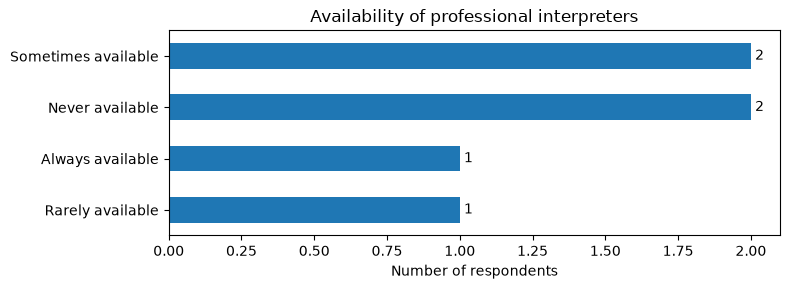

### Reliance on informal interpreters

,Count,Percent
Response,,
Sometimes,3,50.0
Frequently,2,33.3
Always,1,16.7


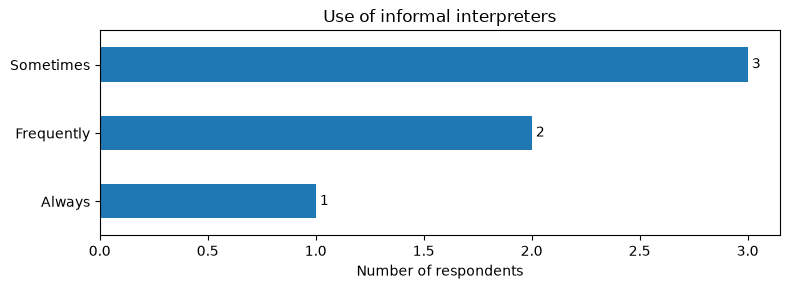

In [11]:
availability_table = frequency_table(clean["professional_interpreter_availability"])
informal_table = frequency_table(clean["informal_interpreter_frequency"])

display(Markdown("### Availability of professional interpreters"))
display(availability_table)
plot_counts(availability_table, "Availability of professional interpreters")

display(Markdown("### Reliance on informal interpreters"))
display(informal_table)
plot_counts(informal_table, "Use of informal interpreters")


## 10. Current communication strategies

The matrix questions record how frequently each strategy is used and how reliable respondents consider it.


### Frequency of use

,Valid responses,Often or always,Mean frequency score (0-4)
Bilingual staff,6,4,2.83
Professional interpreter,6,2,1.83
Family/community member,6,0,1.33
Other,6,0,1.17
Translation app,6,1,0.83
Printed multilingual materials,6,0,0.67


### Perceived reliability

,Valid responses,Mean reliability score (1-5)
Bilingual staff,6,3.83
Professional interpreter,6,3.00
Other,6,3.00
Translation app,6,2.17
Printed multilingual materials,6,1.83
Family/community member,6,1.67


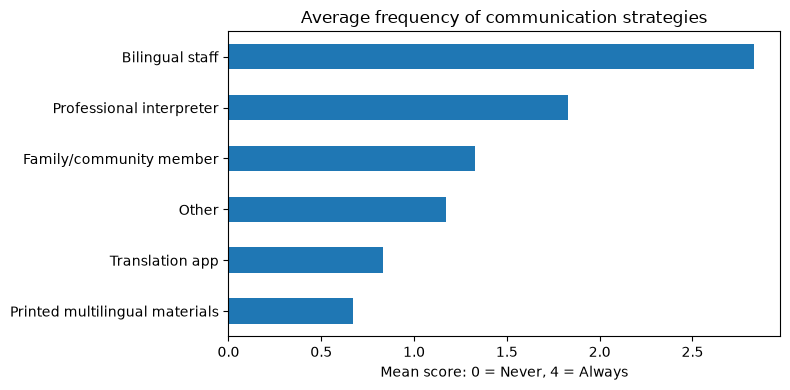

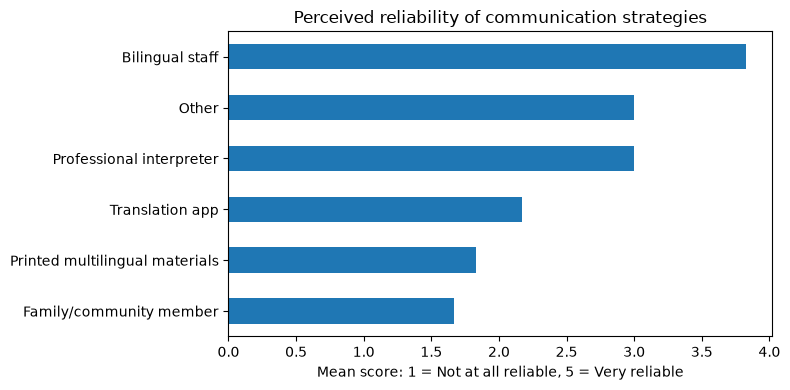

In [12]:
strategy_frequency_columns = {
    "Printed multilingual materials": "group_zy3lg76_row_4_column",
    "Family/community member": "group_zy3lg76_row_2_column",
    "Other": "group_zy3lg76_row_5_column",
    "Professional interpreter": "group_zy3lg76_row_column",
    "Bilingual staff": "group_zy3lg76_row_1_column",
    "Translation app": "group_zy3lg76_row_3_column",
}

strategy_reliability_columns = {
    "Professional interpreter": "group_jf4yt43_row_column",
    "Other": "group_jf4yt43_row_5_column",
    "Printed multilingual materials": "group_jf4yt43_row_4_column",
    "Family/community member": "group_jf4yt43_row_2_column",
    "Translation app": "group_jf4yt43_row_3_column",
    "Bilingual staff": "group_jf4yt43_row_1_column",
}

strategy_frequency = pd.DataFrame({
    name: xml_raw[col].map({
        "option_1": "Never",
        "option_2": "Rarely",
        "option": "Sometimes",
        "option_3": "Often",
        "option_4": "Always",
    })
    for name, col in strategy_frequency_columns.items()
})

strategy_reliability = pd.DataFrame({
    name: xml_raw[col].map({
        "option_1": 1,
        "option_2": 2,
        "option": 3,
        "option_3": 4,
        "option_4": 5,
    })
    for name, col in strategy_reliability_columns.items()
})

frequency_order = {"Never": 0, "Rarely": 1, "Sometimes": 2, "Often": 3, "Always": 4}
frequency_scores = strategy_frequency.apply(lambda col: col.map(frequency_order))

strategy_use_summary = pd.DataFrame({
    "Valid responses": strategy_frequency.notna().sum(),
    "Often or always": frequency_scores.isin([3, 4]).sum(),
    "Mean frequency score (0-4)": frequency_scores.mean().round(2),
}).sort_values("Mean frequency score (0-4)", ascending=False)

strategy_reliability_summary = pd.DataFrame({
    "Valid responses": strategy_reliability.notna().sum(),
    "Mean reliability score (1-5)": strategy_reliability.mean().round(2),
}).sort_values("Mean reliability score (1-5)", ascending=False)

display(Markdown("### Frequency of use"))
display(strategy_use_summary)

display(Markdown("### Perceived reliability"))
display(strategy_reliability_summary)

ax = strategy_use_summary.sort_values("Mean frequency score (0-4)")[
    "Mean frequency score (0-4)"
].plot.barh(figsize=(8, 4), legend=False)
ax.set_title("Average frequency of communication strategies")
ax.set_xlabel("Mean score: 0 = Never, 4 = Always")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

ax = strategy_reliability_summary.sort_values("Mean reliability score (1-5)")[
    "Mean reliability score (1-5)"
].plot.barh(figsize=(8, 4), legend=False)
ax.set_title("Perceived reliability of communication strategies")
ax.set_xlabel("Mean score: 1 = Not at all reliable, 5 = Very reliable")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## 11. Training, infrastructure, and digital tools

### Formal training

,Count,Percent
Response,,
No,4,66.7
Yes,2,33.3


### Device access

,Count,Percent
Response,,
"Yes, provided by my employer",4,66.7
No reliable access,1,16.7
"Yes, but it's my personal device",1,16.7


### Internet reliability

,Count,Percent
Response,,
Reliable most of the time,3,50.0
Reliable sometimes,3,50.0


### Trust in machine translation

,Count,Percent
Response,,
Moderately,2,33.3
Slightly,2,33.3
Not at all,1,16.7
Very,1,16.7


### Barriers limiting digital-tool use

,Count,Percent of respondents
Poor connectivity,4,66.7
Tool doesn't support local languages,4,66.7
Lack of training,3,50.0
Limited device access,2,33.3
"Not applicable, I don't use digital tools",1,16.7


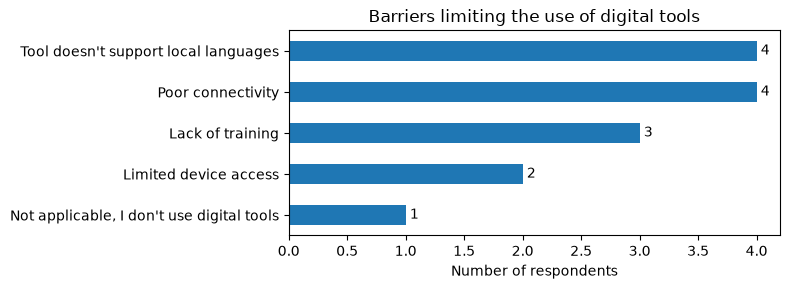

### Support needed for digital translation tools

,Count,Percent of respondents
Staff training,4,66.7
Better internet access,4,66.7
Tools that support local languages,3,50.0
Clear rules on privacy and consent,3,50.0
Employer-provided phones/tablets,2,33.3
Technical support,2,33.3


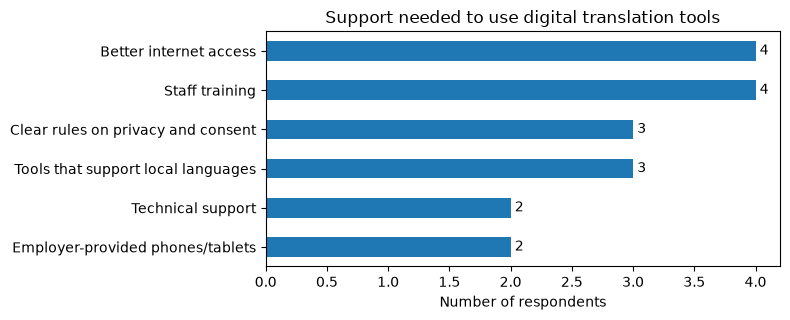

In [13]:
digital_barrier_q = "What barriers limit your use of digital/technological tools?"
digital_support_q = "What support would make digital translation tools easier to use in your workplace?"

digital_barriers = option_matrix(digital_barrier_q)
digital_supports = option_matrix(digital_support_q)

display(Markdown("### Formal training"))
display(frequency_table(clean["formal_training"]))

display(Markdown("### Device access"))
display(frequency_table(clean["device_access"]))

display(Markdown("### Internet reliability"))
display(frequency_table(clean["internet_reliability"]))

display(Markdown("### Trust in machine translation"))
display(frequency_table(clean["machine_translation_trust"]))

display(Markdown("### Barriers limiting digital-tool use"))
digital_barrier_summary = multiselect_summary(digital_barriers, len(clean))
display(digital_barrier_summary)
plot_counts(
    digital_barrier_summary.rename(columns={"Percent of respondents": "Percent"}),
    "Barriers limiting the use of digital tools"
)

display(Markdown("### Support needed for digital translation tools"))
digital_support_summary = multiselect_summary(digital_supports, len(clean))
display(digital_support_summary)
plot_counts(
    digital_support_summary.rename(columns={"Percent of respondents": "Percent"}),
    "Support needed to use digital translation tools"
)


## 12. Priority needs

Weighted score:
- first choice = 3 points;
- second choice = 2 points;
- third choice = 1 point.


,Mentions,First_choice_count,Weighted_score
Priority,,,
More professional interpreters,3,3,9
Formal training,4,1,7
Better translation technology,3,1,6
More bilingual staff,3,1,6
Other,3,0,5
Clearer referral protocols,2,0,3


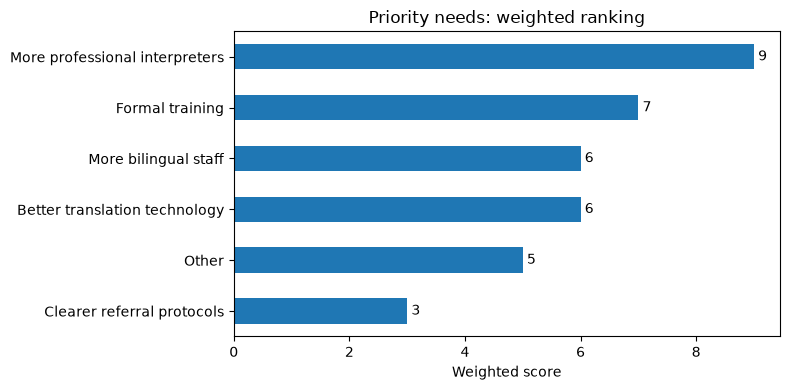

In [14]:
priority_long = clean[["priority_1", "priority_2", "priority_3"]].melt(
    var_name="Rank", value_name="Priority"
).dropna()

weights = {"priority_1": 3, "priority_2": 2, "priority_3": 1}
priority_long["Weight"] = priority_long["Rank"].map(weights)

priority_summary = (
    priority_long.groupby("Priority")
    .agg(
        Mentions=("Priority", "size"),
        First_choice_count=("Rank", lambda x: (x == "priority_1").sum()),
        Weighted_score=("Weight", "sum"),
    )
    .sort_values(["Weighted_score", "First_choice_count"], ascending=False)
)

display(priority_summary)

ax = priority_summary.sort_values("Weighted_score")["Weighted_score"].plot.barh(
    figsize=(8, 4), legend=False
)
ax.set_title("Priority needs: weighted ranking")
ax.set_xlabel("Weighted score")
ax.set_ylabel("")
ax.bar_label(ax.containers[0], padding=3)
plt.tight_layout()
plt.show()


## 13. Preferred digital solution and willingness to pilot

In [15]:
display(Markdown("### Preferred format"))
display(frequency_table(clean["preferred_digital_format"]))

display(Markdown("### Willingness to pilot a free digital communication tool"))
display(frequency_table(clean["willing_to_pilot"]))


### Preferred format

,Count,Percent
Response,,
An AI chatbot for common phrases/instructions,2,33.3
"None, human interpreters are preferable",2,33.3
A mobile app for real-time translation,2,33.3


### Willingness to pilot a free digital communication tool

,Count,Percent
Response,,
Yes,5,83.3
No,1,16.7


## 14. Sector-specific exploratory findings

These questions were shown conditionally according to role or sector. The number of valid responses is very small.


In [16]:
sector_result_rows = []
for variable, question in sector_questions.items():
    valid = clean[variable].dropna()
    if len(valid):
        for response, count in valid.value_counts().items():
            sector_result_rows.append({
                "Variable": variable,
                "Question": question,
                "Response": response,
                "Count": count,
                "Valid responses to question": len(valid),
            })

sector_results = pd.DataFrame(sector_result_rows)
display(sector_results)


,Variable,Question,Response,Count,Valid responses to question
0,health_consent_understanding,How confident are you that patients fully understand consent information when a language barrier is present?,Fairly confident,1,1
1,health_confidentiality,"How often do confidentiality concerns affect your choice of interpreter (e.g., avoiding a known community member for...",Sometimes,1,1
2,health_delayed_access,"In your experience, how often do clients avoid or delay seeking your services because they expect a language barrier?",Sometimes,1,3
3,health_delayed_access,"In your experience, how often do clients avoid or delay seeking your services because they expect a language barrier?",Rarely,1,3
4,health_delayed_access,"In your experience, how often do clients avoid or delay seeking your services because they expect a language barrier?",Always,1,3
5,health_preventive_messaging,"How often do language barriers affect your ability to deliver preventive health messaging (e.g., maternal health, fa...",Rarely,1,1
6,health_clinical_error,"How often do you believe language barriers have contributed to a clinical error or missed diagnosis (e.g., wrong med...",Sometimes,1,1
7,legal_accurate_record,How often do language barriers affect your ability to accurately record a client's statement or case details?,Sometimes,1,2
8,legal_accurate_record,How often do language barriers affect your ability to accurately record a client's statement or case details?,Always,1,2
9,legal_rights_understanding,How confident are you that clients fully understand their legal rights and case procedures when a language barrier i...,Somewhat confident,1,2


## 15. Open-text responses

In [17]:
open_text_candidates = {
    "Other settlement": scalar("Please specify which settlement or refugee-hosting area do you currently work."),
    "Other role": scalar("Please specify your role"),
    "Other client language": coalesce_columns(
        labels_raw, matching_columns(labels_raw, exact="Please specify other language(s)")
    ),
    "Other ranked priority": scalar("If you selected 'Other' in your ranking above, please specify"),
    "Other informal-interpreter concern": scalar("Please specify other concern"),
}

open_text = pd.DataFrame(open_text_candidates)
open_text.insert(0, "Respondent", labels_raw["_index"])
open_text = open_text.dropna(how="all", subset=list(open_text_candidates.keys()))
display(open_text)


,Respondent,Other settlement,Other role,Other client language,Other ranked priority,Other informal-interpreter concern
3,4,NaN,NaN,Kinyabwisha And Kiswahili,NaN,NaN
4,5,NaN,NaN,Kiswahili,NaN,NaN


## 16. Preliminary findings generated from the cleaned data

In [18]:
n = len(clean)

frequent_cross_language = clean["interaction_frequency"].isin(["Often", "Always"]).sum()
low_interpreter_availability = clean["professional_interpreter_availability"].isin(
    ["Never available", "Rarely available"]
).sum()
high_informal_use = clean["informal_interpreter_frequency"].isin(
    ["Frequently", "Often", "Always"]
).sum()
not_trained = clean["formal_training"].astype("string").str.lower().eq("no").sum()
pilot_yes = clean["willing_to_pilot"].astype("string").str.lower().eq("yes").sum()

top_barriers = digital_barrier_summary.index[
    digital_barrier_summary["Count"] == digital_barrier_summary["Count"].max()
].tolist()
top_priority = priority_summary.index[0] if len(priority_summary) else "Not available"
best_strategy = (
    strategy_reliability_summary.index[0]
    if len(strategy_reliability_summary) else "Not available"
)

summary_md = f"""
### Preliminary descriptive interpretation

- The analysis includes **{n} eligible service providers** and **{labels_raw['__version__'].nunique()} form versions**.
- **{frequent_cross_language} out of {n}** respondents reported interacting with clients whose primary language differs from theirs **often or always**.
- **{low_interpreter_availability} out of {n}** rated professional interpreters as **never or rarely available**.
- **{high_informal_use} out of {n}** reported relying on informal interpreters **frequently/often or always**.
- **{not_trained} out of {n}** had not received formal training on working with language-discordant clients.
- The most frequently reported digital barriers were **{", ".join(top_barriers)}**.
- The highest weighted service-improvement priority was **{top_priority}**.
- The strategy with the highest mean perceived reliability was **{best_strategy}**.
- **{pilot_yes} out of {n}** respondents were willing to pilot a new digital communication tool at no cost.

These findings are preliminary and should not be generalised beyond the six respondents.
"""
display(Markdown(summary_md))



### Preliminary descriptive interpretation

- The analysis includes **6 eligible service providers** and **2 form versions**.
- **4 out of 6** respondents reported interacting with clients whose primary language differs from theirs **often or always**.
- **3 out of 6** rated professional interpreters as **never or rarely available**.
- **3 out of 6** reported relying on informal interpreters **frequently/often or always**.
- **4 out of 6** had not received formal training on working with language-discordant clients.
- The most frequently reported digital barriers were **Poor connectivity, Tool doesn't support local languages**.
- The highest weighted service-improvement priority was **More professional interpreters**.
- The strategy with the highest mean perceived reliability was **Bilingual staff**.
- **5 out of 6** respondents were willing to pilot a new digital communication tool at no cost.

These findings are preliminary and should not be generalised beyond the six respondents.


## 17. Export the cleaned dataset and summary tables

The notebook exports a harmonised respondent-level CSV and summary CSV files.


In [ ]:
# Create the output folder for summary CSV files if it does not already exist.
OUTPUT_DIR = DATA_DIR / "service_provider_analysis_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# Remove raw intermediate ordinal columns before exporting the cleaned dataset.
clean_export = clean.drop(
    columns=[c for c in clean.columns if c.endswith("_raw")],
    errors="ignore",
)

clean_export.to_csv(OUTPUT_DIR / "service_provider_cleaned.csv", index=False)
priority_summary.to_csv(OUTPUT_DIR / "priority_summary.csv")
digital_barrier_summary.to_csv(OUTPUT_DIR / "digital_barrier_summary.csv")
strategy_use_summary.to_csv(OUTPUT_DIR / "strategy_frequency_summary.csv")
strategy_reliability_summary.to_csv(OUTPUT_DIR / "strategy_reliability_summary.csv")

print("Files saved in:", OUTPUT_DIR)
for path in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", path.name)

Files saved in: data\service_provider_analysis_outputs
- digital_barrier_summary.csv
- digital_support_summary.csv
- priority_summary.csv
- service_provider_cleaned.csv
- strategy_frequency_summary.csv
- strategy_reliability_summary.csv


## 18. Next step

After reviewing the harmonisation table, descriptive results, and charts, the validated findings can be transformed into the formal results report.

The report should clearly distinguish:
- findings based on all six respondents;
- questions answered by only three respondents because of form-version or skip-logic differences;
- sector-specific questions answered by only one or two respondents;
- qualitative observations that cannot be generalised.
